#### CELL PHONE PRICE

In [2]:
!pip install numpy pandas matplotlib seaborn

In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

In [4]:
# LOAD DATASET
df = pd.read_csv(r"C:\Users\bisha\Downloads\datasets.csv")

# Display first 5 rows
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
#BASIC DATA UNDERSTANDING
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

Shape: (2000, 21)

Missing Values:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Statistics:
        battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
min       501.000000     0.0000     0.500000     0.000000     0.000000   
25%       851.750000     0.0000     0.700000     0.000000     1.000000   
50%      1226.000000     0.0000     1.500000     1.000000     3.000000   
75%      1615.250000

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


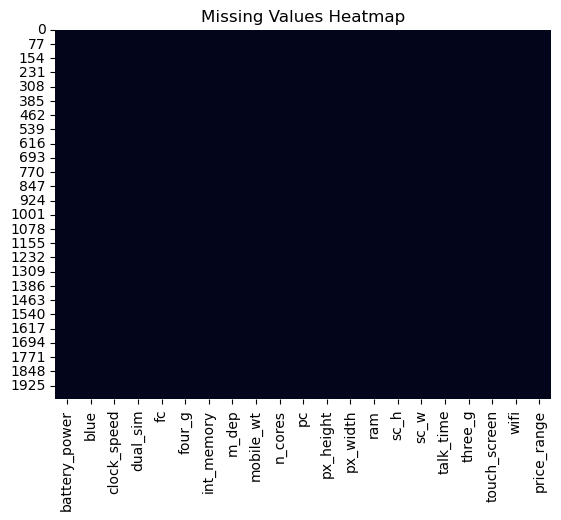

In [6]:
# CHECK MISSING VALUES (IMPORTANT FIX)
print(df.isnull().sum())
# Visualization of missing values
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

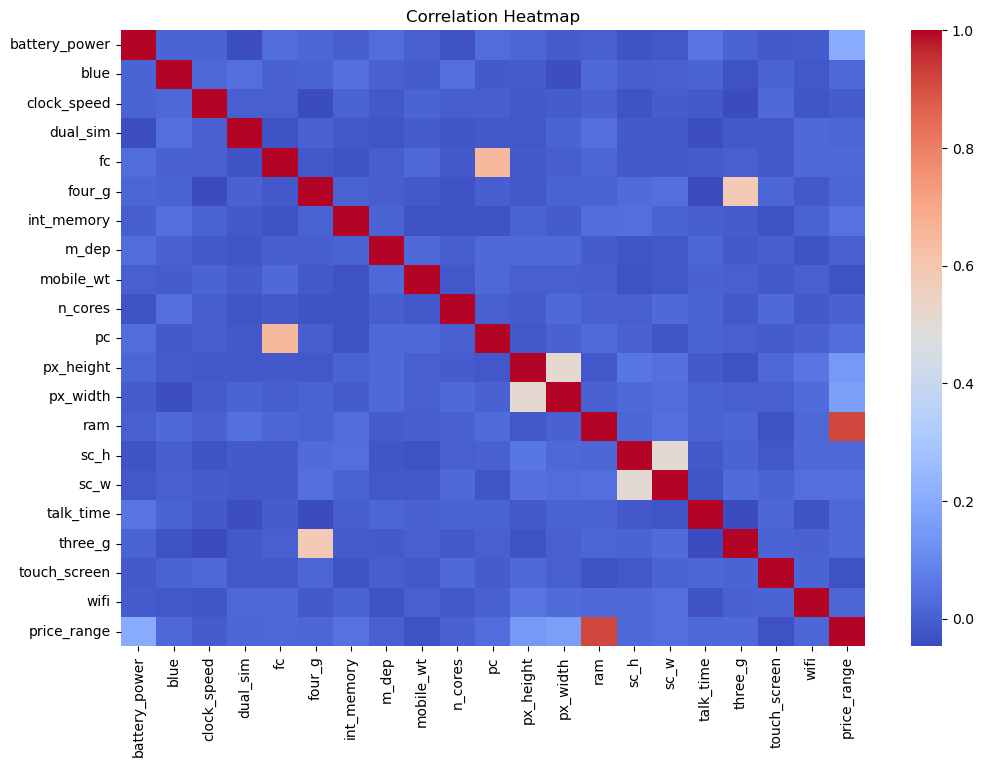

In [7]:
# CORRELATION HEATMAP WITH INSIGHTS
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

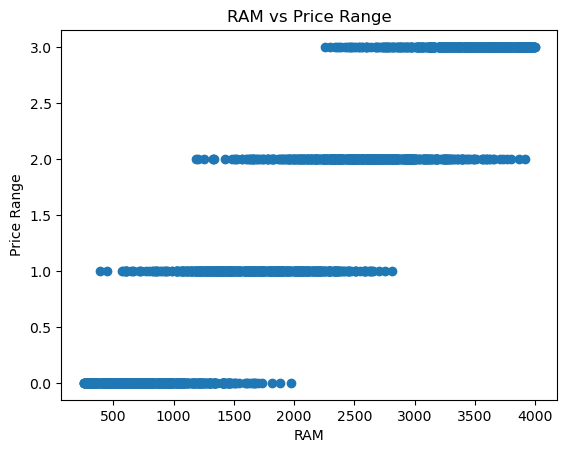

In [8]:
# SCATTER PLOT (WITH INSIGHT ADDED)
plt.scatter(df['ram'], df['price_range'])
plt.xlabel("RAM")
plt.ylabel("Price Range")
plt.title("RAM vs Price Range")
plt.show()

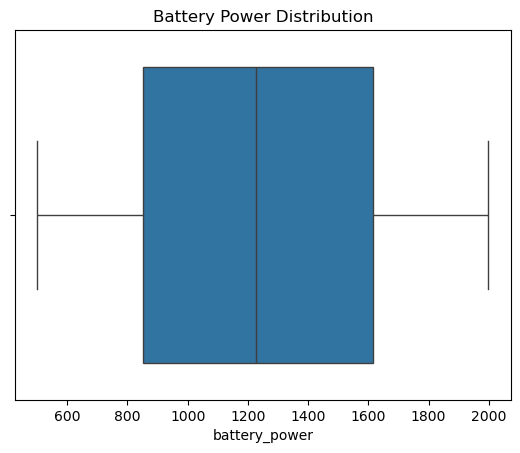

In [9]:
# BOX PLOT (OUTLIER ANALYSIS)
sns.boxplot(x=df['battery_power'])
plt.title("Battery Power Distribution")
plt.show()

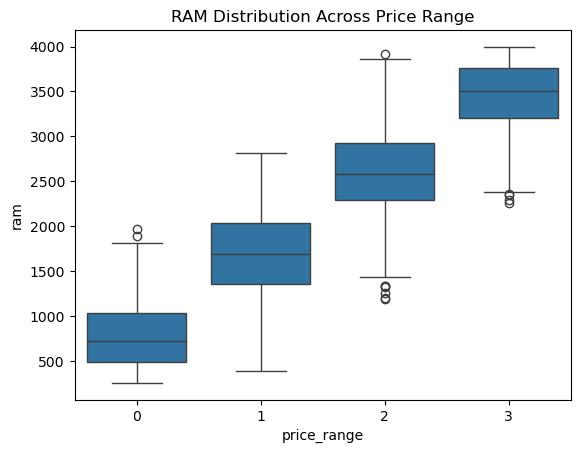

In [10]:
# ADDITIONAL VISUALIZATION
sns.boxplot(x=df['price_range'], y=df['ram'])
plt.title("RAM Distribution Across Price Range")
plt.show()

# Insight:
# Higher price groups clearly have higher RAM

In [8]:
# FEATURE SELECTION / DROPPING
# No unnecessary columns here → dataset already clean
# (In your previous project you dropped columns – now justify properly)

X = df.drop('price_range', axis=1)
y = df['price_range']

In [9]:
# FEATURE SCALING (ADDED IMPROVEMENT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
#LOGISTIC REGRESSION
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

y_pred_log = log.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

In [11]:
# LINEAR REGRESSION MODEL
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 0.323562825613986
Linear Regression R2: 0.9215339010437136


In [12]:
#RANDOM FOREST
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

# Convert regression output to class
y_pred_rf_class = np.round(y_pred_rf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_class))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_class))

Random Forest RMSE: 0.26788197027795657
Random Forest R2: 0.9462161617770366
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [13]:
# MODEL COMPARISON
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf_class)
    ]
})
print(results)

               Model      RMSE  R2 Score
0  Linear Regression  0.323563  0.921534
1      Random Forest  0.267882  0.946216


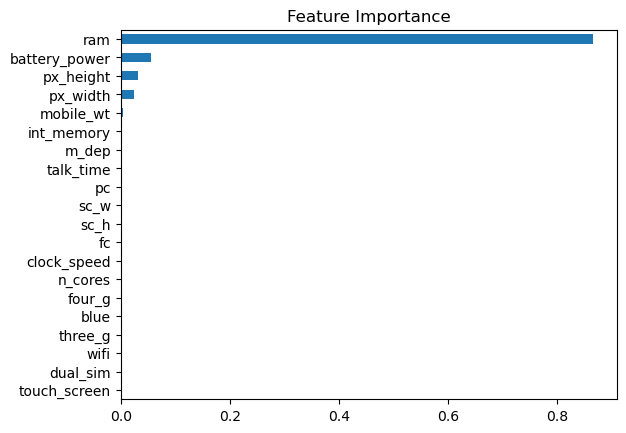

In [16]:
# FEATURE IMPORTANCE
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()